# Math 189 Final Project

## Introduction

**Description of Dataset**

This dataset can be described by the following:
- **Instances**: 39797
- **Features**: 58
- **Types of Predictors**: All predictors are continuous, the only categorical column is 'url' which is removed since we know that all observations are unique articles.

- **Missingness**: No missing values 

The definitions below are cited directly from the dataset authors.For our purposes, we are interested in exploring the following features describing the structural components of an article:

**Type of Article (Channel)**:
- `data_channel_is_lifestyle`: Is data channel 'Lifestyle'?

- `data_channel_is_entertainment`: Is data channel 'Entertainment'?

- `data_channel_is_bus`: Is data channel 'Business'?

- `data_channel_is_socmed`: Is data channel 'Social Media'?

- `data_channel_is_tech`: Is data channel 'Tech'?

- `data_channel_is_world`: Is data channel 'World'?

**Textual Features and Content**
- `n_tokens_title`: Number of words in the title

- `n_tokens_content`: Number of words in the content

- `n_unique_tokens`: Rate of unique words in the content

- `n_non_stop_words`: Rate of non-stop words in the content

- `n_non_stop_unique_tokens`: Rate of unique non-stop words in the content
- `num_imgs`: Number of images

- `num_videos`: Number of videos

**Temporal Features**
We maintain the `weekday_is` columns as they are the one-hot encoded columns for the day while the `is_weekend` column is a binary flag comparing all the weekdays against the weekend. 

- `weekday_is_monday`: Was the article published on a Monday

- `weekday_is_tuesday`: Was the article published on a Tuesday

- `weekday_is_wednesday`: Was the article published on a Wednesday

- `weekday_is_thursday`: Was the article published on a Thursday

- `weekday_is_friday`: Was the article published on a Friday

- `weekday_is_saturday`: Was the article published on a Saturday

- `weekday_is_sunday`: Was the article published on a Sunday

- `is_weekend`: Was the article published on the weekend?

**Sentiment Features**

Full Article Sentiment:

- `global_subjectivity`: Text subjectivity

- `global_sentiment_polarity`: Text sentiment polarity

- `global_rate_positive_words`: Rate of positive words in the content

- `global_rate_negative_words`: Rate of negative words in the content

Title Sentiment: 
- `title_subjectivity`: Title subjectivity
- `title_sentiment_polarity`: Title polarity

Target: Virality using the number of shares
- `shares`: Number of shares (target)

- `is_viral`: Binary column indicating whether the article went viral. We add this column to the dataset.<sup>1</sup>

---

<sup>1</sup> We define virality as any article in the top 10% of shares.

## Data Cleaning

Here, we extract the features we are interested in and create a new column for our response variable, is_viral.

In [1]:
#necessary ml and data processing packages
import pandas as pd
import numpy as np
import scipy.stats as stats
import sklearn

#necessary statsmodels packages
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import acf

In [1]:
#load files
path = "OnlineNewsPopularity/OnlineNewsPopularity.csv"
online = pd.read_csv(path)


NameError: name 'pd' is not defined

In [3]:
#strip the extra whitespace from column headers
online.columns = online.columns.str.strip()

#extract features: the only categorical column is url, but we know they are all unique so remove
features = ['data_channel_is_lifestyle', 'data_channel_is_bus', 'data_channel_is_socmed','data_channel_is_tech','data_channel_is_entertainment', 'data_channel_is_world',
            'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_imgs', 'num_videos', 
            'weekday_is_monday','weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 
            'is_weekend', 'global_subjectivity', 'global_sentiment_polarity', 'rate_positive_words', 'rate_negative_words', 
            'title_subjectivity','title_sentiment_polarity', 'shares']

online = online[features]

#adding in target variable
virality_threshold = online['shares'].quantile(0.9)
online['is_viral'] = (online['shares'] >= virality_threshold).astype(int)

#counting how many viral articles there are
num_viral = online[online['is_viral'] == 1].shape[0]
print(f'There are {num_viral} viral articles in the dataset.')

online.head()

There are 4029 viral articles in the dataset.


,data_channel_is_lifestyle,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_entertainment,data_channel_is_world,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,...,weekday_is_sunday,is_weekend,global_subjectivity,global_sentiment_polarity,rate_positive_words,rate_negative_words,title_subjectivity,title_sentiment_polarity,shares,is_viral
0,0.0,0.0,0.0,0.0,1.0,0.0,12.0,219.0,0.663594,1.0,...,0.0,0.0,0.521617,0.092562,0.769231,0.230769,0.500000,-0.187500,593,0
1,0.0,1.0,0.0,0.0,0.0,0.0,9.0,255.0,0.604743,1.0,...,0.0,0.0,0.341246,0.148948,0.733333,0.266667,0.000000,0.000000,711,0
2,0.0,1.0,0.0,0.0,0.0,0.0,9.0,211.0,0.575130,1.0,...,0.0,0.0,0.702222,0.323333,0.857143,0.142857,0.000000,0.000000,1500,0
3,0.0,0.0,0.0,0.0,1.0,0.0,9.0,531.0,0.503788,1.0,...,0.0,0.0,0.429850,0.100705,0.666667,0.333333,0.000000,0.000000,1200,0
4,0.0,0.0,0.0,1.0,0.0,0.0,13.0,1072.0,0.415646,1.0,...,0.0,0.0,0.513502,0.281003,0.860215,0.139785,0.454545,0.136364,505,0


### Column Standardization

In [4]:
predictors_to_standardize = [
    "n_tokens_title",
    "n_tokens_content",
    "num_imgs",
    "num_videos",
    "global_sentiment_polarity",
    "global_subjectivity",
    "rate_positive_words",
    "rate_negative_words",
]

channel_cols = [
    'data_channel_is_lifestyle',
    'data_channel_is_entertainment',
    'data_channel_is_bus',
    'data_channel_is_socmed',
    'data_channel_is_tech',
    'data_channel_is_world'
]
binary_predictor = ['is_weekend']

In [5]:
def standardize(df, columns):
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        df[f"z_{col}"] = (df[col] - mean) / std
    return df

def collapse_channel_columns(df, channel_cols):
    """
    Turn all precious binary channel columns into a single 
    categorical column.
    """
    df = df.copy()
    df["channel"] = "other"
    
    for column in channel_cols:
        label = column.replace("data_channel_is_", "")
        df.loc[df[column] == 1, "channel"] = label
    
    return df


In [6]:
online = standardize(online, predictors_to_standardize)
online = collapse_channel_columns(online, channel_cols)
standardized_cols = [f"z_{col}" for col in predictors_to_standardize]
cols_to_keep = standardized_cols + ["channel", "is_weekend", "shares", "is_viral"]
# cols_to_keep

online = online[cols_to_keep]

In [7]:
#specific type cast for ols
online['channel'] = online['channel'].astype('category')

## EDA
Here, we conduct univariate analyses on our predictors and assess normality.

In [8]:
#plotting packages
import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

### Test Assumptions: Normality

Here, we check the skewness of each predictor against it's response variable.

In [9]:
online.columns

Index(['z_n_tokens_title', 'z_n_tokens_content', 'z_num_imgs', 'z_num_videos',
       'z_global_sentiment_polarity', 'z_global_subjectivity',
       'z_rate_positive_words', 'z_rate_negative_words', 'channel',
       'is_weekend', 'shares', 'is_viral'],
      dtype='object')

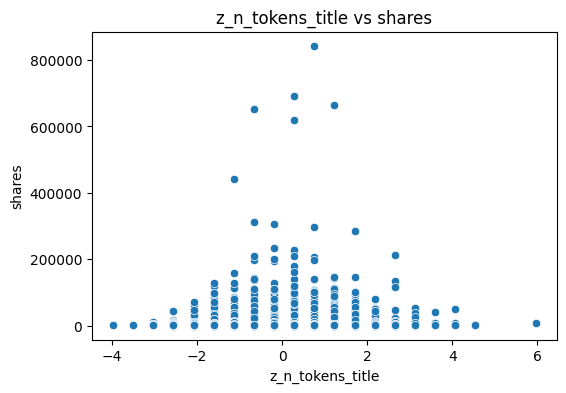

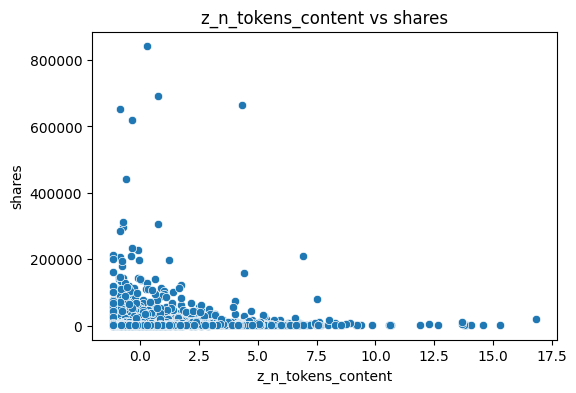

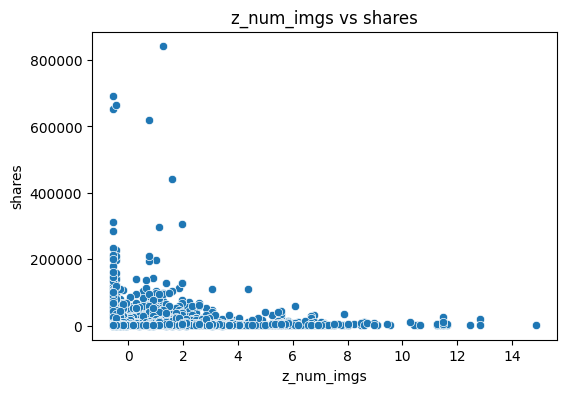

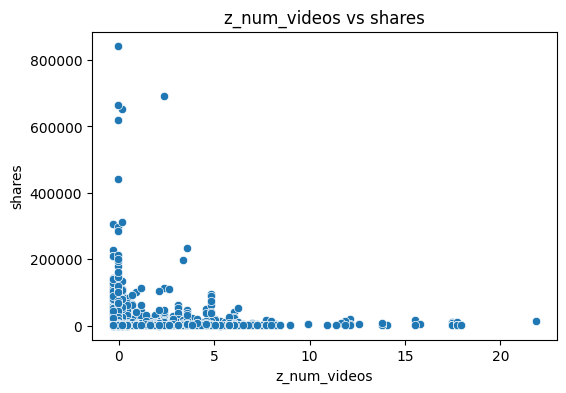

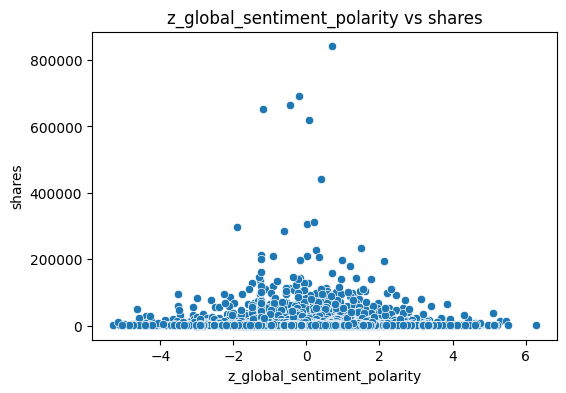

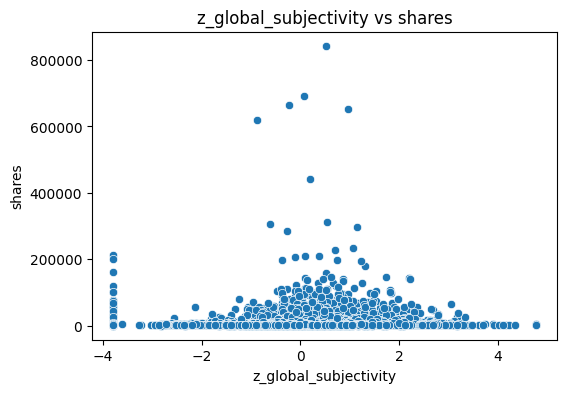

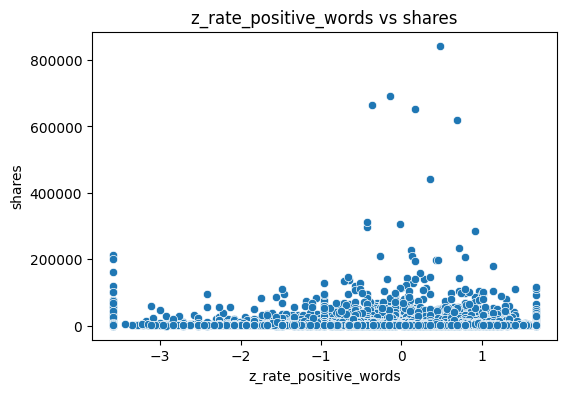

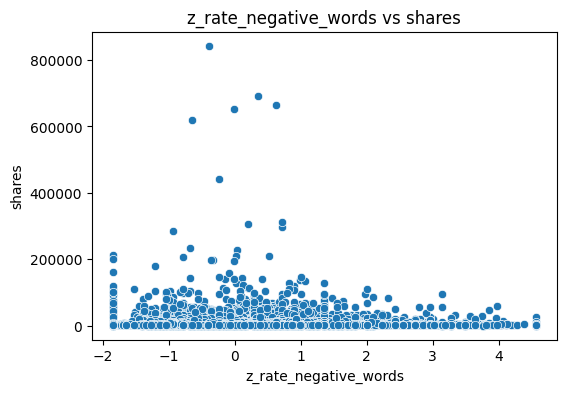

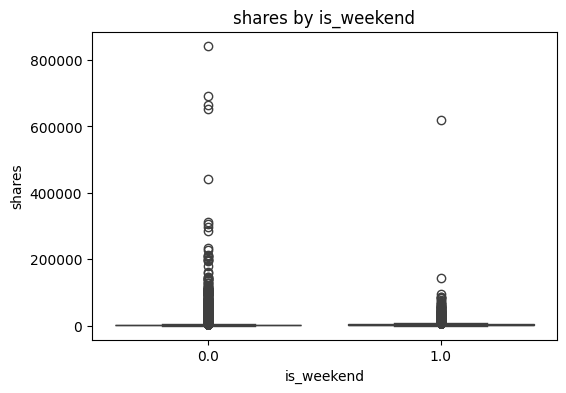

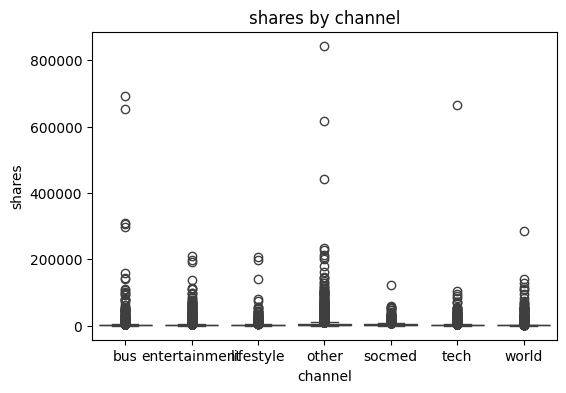

In [ ]:
continuous = ['z_n_tokens_title', 'z_n_tokens_content', 'z_num_imgs', 'z_num_videos',
       'z_global_sentiment_polarity', 'z_global_subjectivity',
       'z_rate_positive_words', 'z_rate_negative_words']
categorical_cols = ['is_weekend', 'channel']  
response_col = 'shares'

# continuous
for col in continuous:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=online[col], y=online[response_col])
    plt.title(f"{col} vs {response_col}")
    plt.show()

# categorical: come back and fix to correctly format as box plots
for col in categorical_cols:
    online[col] = online[col].astype('category') 
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=col, y=online[response_col], data=online)
    plt.title(f"{response_col} by {col}")
    plt.xlabel(col)
    plt.ylabel(response_col)
    plt.show()

Here, we fit a linear regression model on all our features of interest and check for normality. By fitting a linear regression on our model soley on standardized features and binary features, we notice that we do not satisfy normality. We approach this by applying a log transformation to our predictors.

In [11]:
#fitting a linear regression model purely on the standardized and binary columns
x_values = (
    "z_n_tokens_title + z_n_tokens_content + z_num_imgs + z_num_videos + "
    "is_weekend + z_global_sentiment_polarity + z_global_subjectivity + "
    "z_rate_positive_words + z_rate_negative_words + "
    "C(channel, Treatment(reference='world'))"
)

model = smf.ols(
    formula=f"shares ~ {x_values}",
    data=online
).fit()

In [12]:
def check_for_normality(model):
    """Assess normality of the residuals after fitting a linear regression model"""
    residuals = [model.resid]  

    #subplots
    fig, axs = plt.subplots(2, 1, figsize=(10, 10))

    for resid in residuals:
        # Standardize residuals manually
        resid_std = (resid - resid.mean()) / resid.std()

        #histogram
        sns.histplot(resid_std, bins=20, kde=True, ax=axs[0])
        axs[0].set_title('Histogram of Standardized Residuals')
        axs[0].set_xlabel('Standardized Residuals')
        axs[0].set_ylabel('Frequency')

        # Q-Q plot
        sm.qqplot(resid_std, line='45', ax=axs[1])
        axs[1].set_title('Q-Q Plot of Standardized Residuals')

    plt.tight_layout()
    plt.show()
    

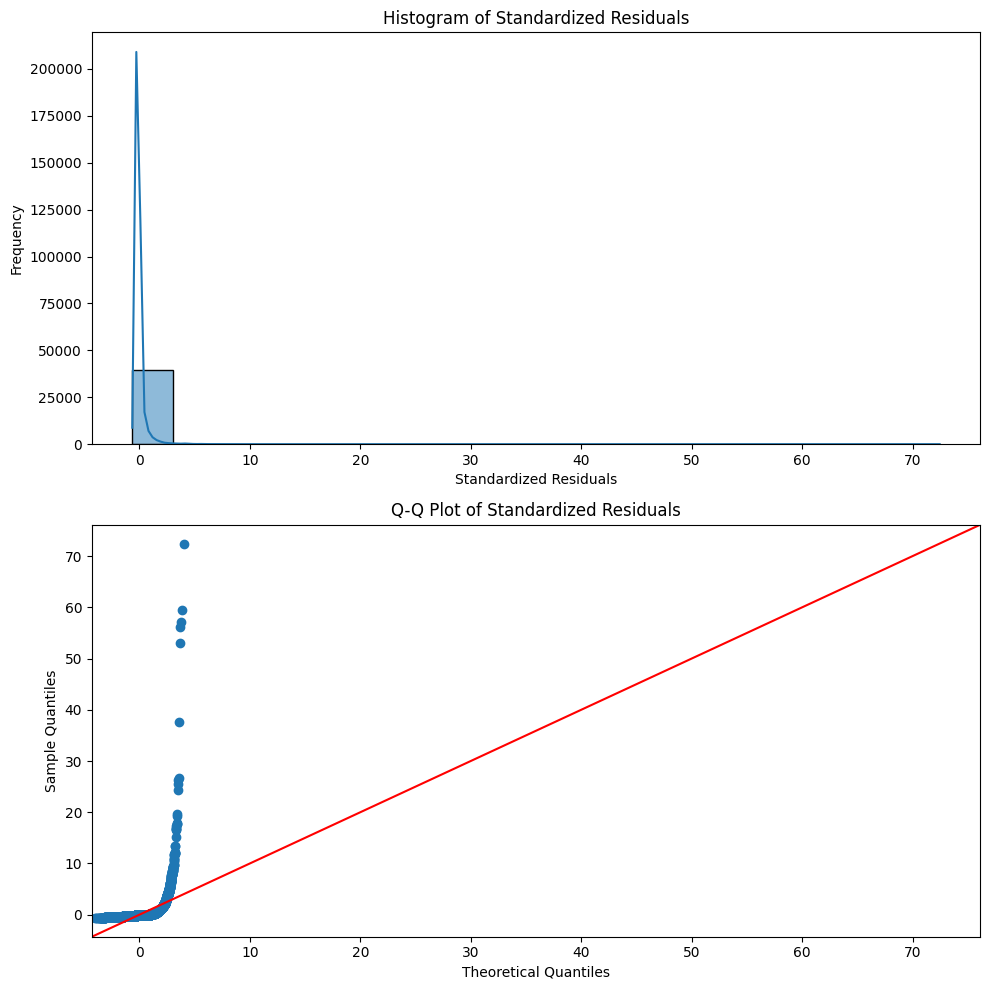

In [13]:
check_for_normality(model)

### Test Assumptions: Heteroschedascity

### Continuous Predictors

Here, we conduct non-parametric testing (KS tests) on our data.

### Categorical Predictors

Here, we conduct tests on our categorical predictors: `is_weekend` and `channel`.